In [5]:
import numpy as np
import matplotlib.pyplot as plt

import skimage

In [6]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import py_deffields.fields.analytic as analytic
from py_deffields.warp import warp

(128, 128, 128)


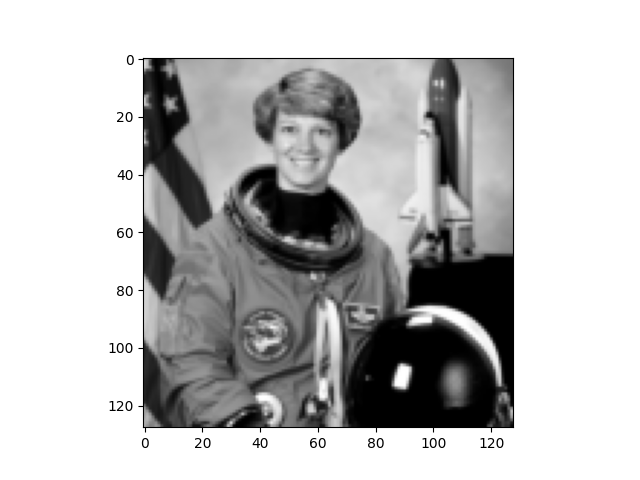

In [40]:
image = skimage.data.astronaut()
image = skimage.color.rgb2gray(image)
image = skimage.transform.resize(image, (128, 128))

volume = np.repeat(image[:, :, np.newaxis], 128, axis=-1)
print(volume.shape)

fig, ax = plt.subplots()
ax.imshow(
    volume[:, :, 32],
    cmap='gray',
)

In [41]:
from py_deffields.visualization.quiver import QuiverVisualizer

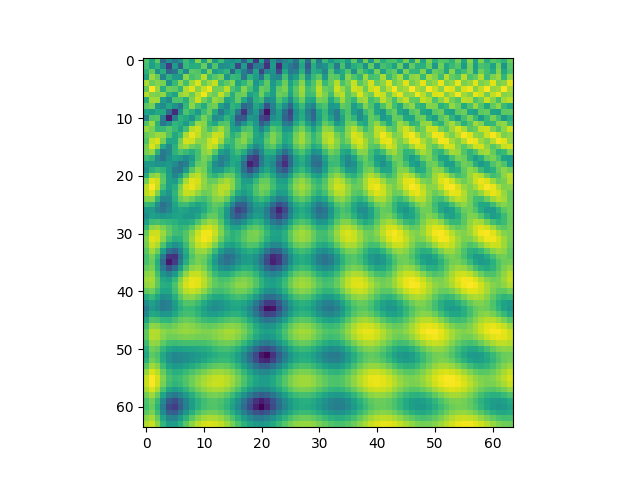

In [55]:
# Volume shape for testing
SHAPE = (64, 64, 64)
MAX_DISP = 16.0

# Random seed for reproducibility
SEED = 42
# Create RNG for reproducibility
rng = np.random.default_rng(SEED)

# Generate all field types
fields = {}

fields['star'] = analytic.generate_star(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    rng=np.random.default_rng(SEED),
)

field = fields['star']

fig, ax = plt.subplots()
ax.imshow(
    np.linalg.norm(field, axis=-1)[:, :, 32],
    cmap='viridis',
)

In [67]:
rng = np.random.default_rng(12315)

displacement_field = analytic.generate_star(
    shape=volume.shape,
    max_displacement=4.0,
    rng=rng,
)

In [68]:
displacement_field.shape

(128, 128, 128, 3)

In [69]:
qv = QuiverVisualizer.create(displacement_field)
qv.ux

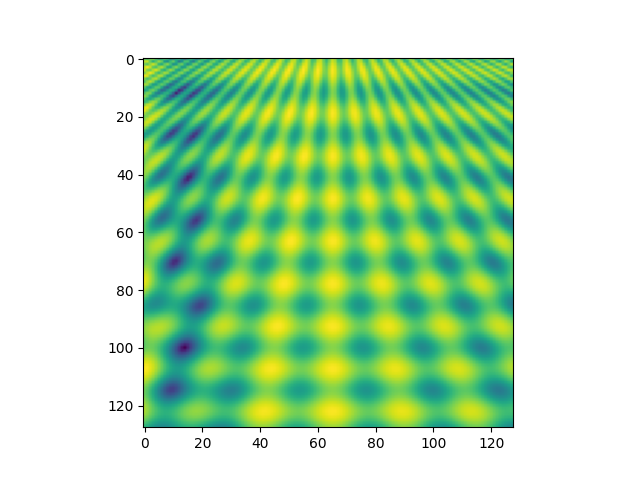

In [70]:
fig, ax = plt.subplots()
ax.imshow(
    np.linalg.norm(displacement_field, axis=-1)[:, :, 64],
    cmap='viridis',
)

In [74]:
from py_deffields.noise.perlin import generate_perlin

In [75]:

# stats of the displacement field
noise = generate_perlin(
    shape=volume.shape,
    scale=16.0,
    octaves=2,
)

warped_volume = warp(
    volume=volume,
    displacement=displacement_field,
)


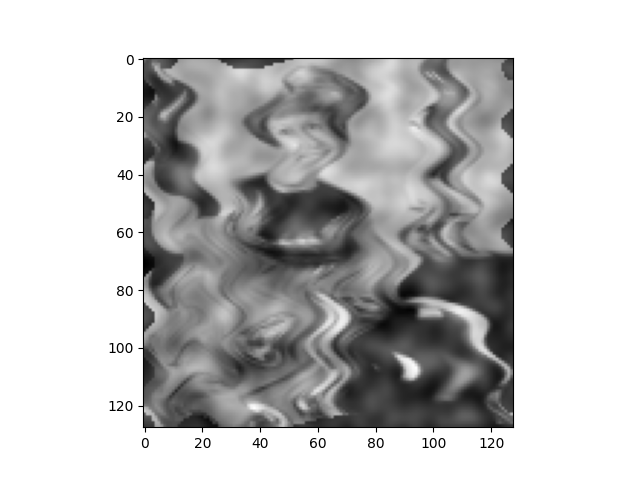

In [78]:
fig, ax = plt.subplots()
ax.imshow(
    (warped_volume + noise)[:, :, 32],
    cmap='gray',
)